# 04 — Regression Analysis

**Goal:** Quantify the relationship between obesity and diabetes prevalence.

**Method:** Ordinary Least Squares (OLS) linear regression.
- Pooled regression: all 6 countries combined
- Per-country regression: individual slopes and R²

**Key finding:** Pooled R²=0.41 (p<0.001). Denmark shows a negative slope (−0.06),
the only country where obesity and diabetes trends have decoupled.

In [1]:
import sys
sys.path.append('..')

import pandas as pd

df = pd.read_csv('../data/nordic_cleaned.csv')
print(df.shape)
df.head()

(198, 6)


,country,iso,year,diabetes_prevalence,treatment_rate,obesity_prevalence
0,Denmark,DNK,1990,0.026467,0.318880,8.57632
1,Denmark,DNK,1991,0.027161,0.323102,8.82850
2,Denmark,DNK,1992,0.027819,0.327693,9.09095
3,Denmark,DNK,1993,0.028435,0.332619,9.36231
4,Denmark,DNK,1994,0.028977,0.337866,9.64552


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

# Drop rows with missing values
df_reg = df.dropna(subset=['obesity_prevalence', 'diabetes_prevalence'])

x = df_reg['obesity_prevalence'].values
y = df_reg['diabetes_prevalence'].values * 100

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²:        {r_value**2:.4f}")
print(f"P-value:   {p_value:.6f}")

Slope:     0.1765
Intercept: 1.7115
R²:        0.4104
P-value:   0.000000


### Per-country regression
Denmark's negative slope is statistically significant (p=0.005),
consistent with the impact of Denmark's fat tax introduced in 2011.

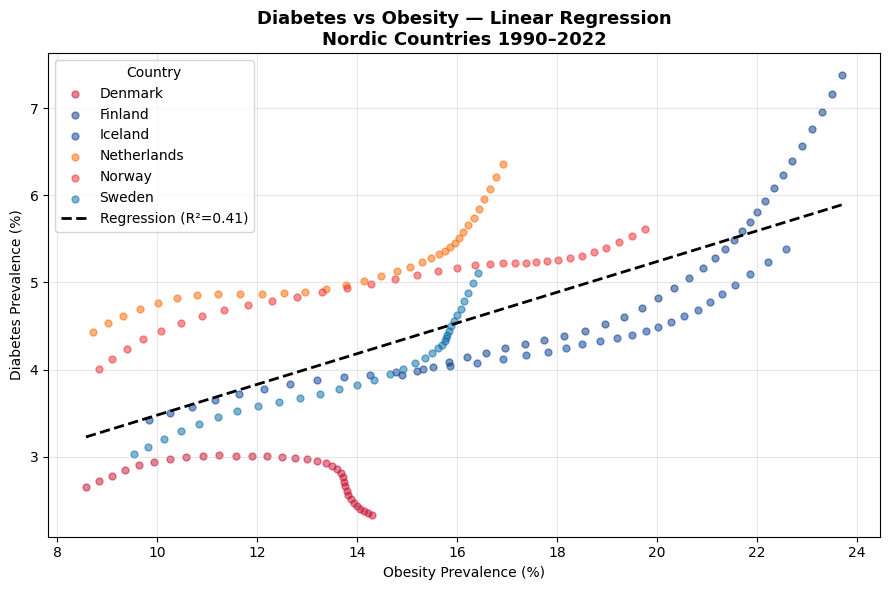

In [3]:
nordic_colors = {
    'Sweden': '#006AA7',
    'Norway': '#EF2B2D',
    'Denmark': '#C60C30',
    'Finland': '#003580',
    'Iceland': '#003897',
    'Netherlands': '#FF6600'
}

fig, ax = plt.subplots(figsize=(9, 6))

for country, group in df_reg.groupby('country'):
    ax.scatter(group['obesity_prevalence'],
               group['diabetes_prevalence'] * 100,
               label=country,
               color=nordic_colors[country],
               alpha=0.5, s=25)

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--',
        label=f'Regression (R²={r_value**2:.2f})')

ax.set_title('Diabetes vs Obesity — Linear Regression\nNordic Countries 1990–2022',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Obesity Prevalence (%)')
ax.set_ylabel('Diabetes Prevalence (%)')
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/regression.png', dpi=150)
plt.show()

In [4]:
print(f"{'Country':<15} {'Slope':>8} {'R²':>8} {'P-value':>12}")
print("-" * 45)

for country, group in df_reg.groupby('country'):
    g = group.dropna()
    s, i, r, p, _ = stats.linregress(g['obesity_prevalence'],
                                      g['diabetes_prevalence'] * 100)
    print(f"{country:<15} {s:>8.4f} {r**2:>8.4f} {p:>12.6f}")

Country            Slope       R²      P-value
---------------------------------------------
Denmark          -0.0595   0.2280     0.004949
Finland           0.3512   0.8712     0.000000
Iceland           0.1213   0.9083     0.000000
Netherlands       0.1649   0.7817     0.000000
Norway            0.1154   0.9495     0.000000
Sweden            0.2382   0.8841     0.000000
